In [2]:
# SVM--> Support Vector Machine
# two types:
    # 1.SVC -->Support Vector Classfier
    # 2.SVR -->Support Vector Regression
# its a supervised lerning model which divides the label into 2 grps separated by a line called HyperPlane when 
# given some binary classification data
# line with maximum distance between 2 classes is called Margin
# Hard and Soft Margin SVMs

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

In [5]:
data=load_breast_cancer()
x=data.data
y=data.target
pca=PCA(n_components=2)
x=pca.fit_transform(x)

In [6]:
xTrain,xTest,yTrain,yTest=train_test_split(x,y,test_size=0.2,random_state=84)
sc=StandardScaler()
xTrain=sc.fit_transform(xTrain)
xtest=sc.transform(xTest)

In [10]:
model=SVC(kernel="linear",C=1)
model.fit(xTrain,yTrain)
yPred=model.predict(xTest)
print("Accuracy :",accuracy_score(yTest,yPred))

Accuracy : 0.9385964912280702


In [22]:
def plot(model,x,y):
    plt.figure(figsize=(10,8))
    plt.scatter(x[:,0],x[:,1],c=y,cmap="coolwarm")
    ax=plt.gca()
    xlim=ax.get_xlim()
    ylim=ax.get_ylim()
    xx=np.linspace(xlim[0],xlim[1],100)
    yy=np.linspace(ylim[0],ylim[1],100)
    yyy,xxx=np.meshgrid(yy,xx)
    xy=np.vstack([xxx.ravel(),yyy.ravel()]).T
    z=model.decision_function(xy)
    z=z.reshape(xxx.shape)
    ax.contour(xxx,yyy,z,levels=[0],colors="black")
    ax.contour(xxx,yyy,z,levels=[-1,1],colors="grey",linestyles="dashed")
    ax.scatter(
        model.support_vectors_[:,0],
        model.support_vectors_[:,1],
        s=120,
        facecolors="none",
        edgecolors="black")
    plt.title("Linear SVM Decision Boundary")
    plt.show()

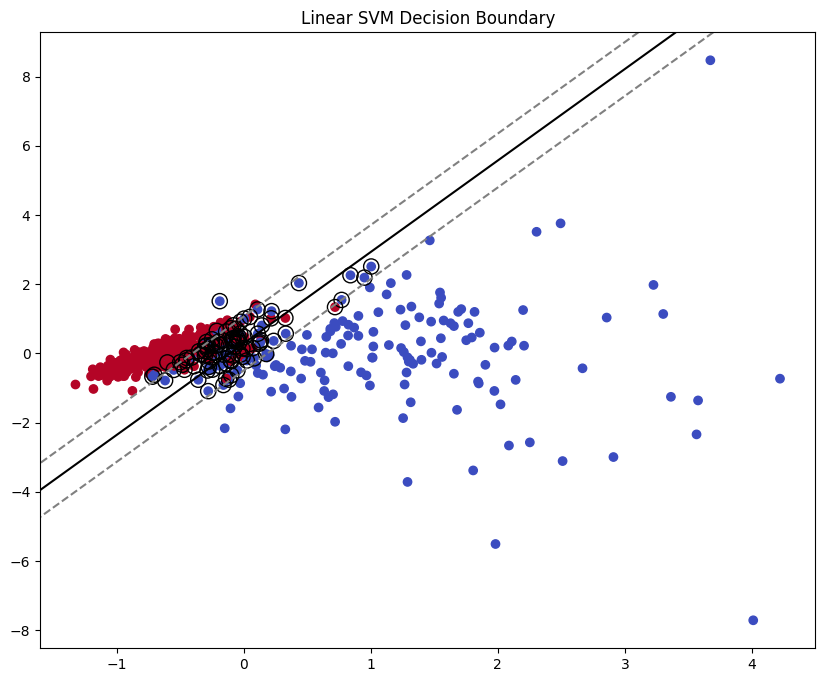

In [23]:
plot(model,xTrain,yTrain)
